In [1]:
%load_ext autoreload
%autoreload 2
import scMPRAforge as scm
import pandas as pd


2025-09-05 14:33:47.015896: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-05 14:33:47.898064: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libcudart.so.11.0'; dlerror: libcudart.so.11.0: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /vast/palmer/apps/avx2/software/code-server/4.91.1/lib:/vast/palmer/apps/avx2/software/gettext/0.22.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libiconv/1.17-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/ncurses/6.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/libxml2/2.12.7-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/XZ/5.4.5-GCCcore-13.3.0/lib:/vast/palmer/apps/avx2/software/expat/2.6.2-GCCcore-13.3.0/lib:/vast/palmer/apps/av

## Test wald test

In [2]:

#create dask cluster
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(n_workers=10)
client = Client(cluster)

path="/gpfs/gibbs/pi/reilly/tabula_data/shendure"
name="ortho_primordial"
precomp_name = 'ortho_primordial_wald_precomp'

import os
if os.path.isdir(path+"/"+precomp_name):
    print("[+]PreComp Model found. Loading...")
    primordial=scm.ortho.load(client,path,precomp_name)
    shendure=primordial.training_data
elif os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    shendure=primordial.training_data
    primordial.precompute_wald(client)
    primordial.save(path, precomp_name) 


[+]PreComp Model found. Loading...


In [3]:
# by-cell-type: test many CREs in NeuroectodermBrain vs the 'reference' negative control
hs_ct = scm.make_by_celltype_hypotheses(
    comparison_cell_type="NeuroectodermBrain",
    counts=shendure,
    comparison_cres="all",          # or a list like ["CRE1","CRE2",...]
    reference_cre="reference",      # this is how you labeled minP/noP
    meta="emvar_screen"
)

# by-CRE: test CRE123 across all cell types vs the baseline cell type
hs_cre = scm.make_by_cre_hypotheses(
    comparison_cre="ubcP",
    counts=shendure,
    comparison_cell_types="all",    # or a list
    reference_cell_type="reference",   # will default to counts.reference_cell_type if set
    meta="cell_specificity"
)

# all CREs within each cell type, vs the 'reference' negative control
hs_all_ct = scm.make_all_by_celltype_hypotheses(
    counts=shendure,
    reference_cre="reference",
    meta="emvar_screen",
)

# all cell types for each CRE, vs the dataset’s baseline cell type
hs_all_cre = scm.make_all_by_cre_hypotheses(
    counts=shendure,
    reference_cell_type="reference",  # will be normalized to 'reference'
    meta="cell_specificity",
)




In [4]:
runner = scm.HypothesisTester("wald")
wald_by_ct  = runner.run(hs_all_ct, primordial, client)
wald_by_cre = runner.run(hs_all_cre, primordial, client)

In [5]:
runner = scm.HypothesisTester("mwu", alternative="two-sided")  # can override defaults here
mwu_res_ct = runner.run(hs_all_ct, shendure, client=client)
mwu_res_cre = runner.run(hs_all_cre, shendure, client=client)

In [6]:
rep_to_biol = {"A1": "A", "A2": "A", "B1": "B", "B2": "B", "2B1":"2B", "2B2":"2B"}

runner = scm.HypothesisTester(
    "bootstrap_activity",
    n_bootstraps=10_000,
    rng_seed=1337,
    rep_to_biol=rep_to_biol, # optional
)
res_boot = runner.run(hs_all_ct, shendure, client)
res_boot.to_dataframe()

,comparison_CRE,comparison_cell_type,reference_CRE,reference_cell_type,meta,test_statistic,p_value,fold_change,flattened,test_type,bh_p
0,Bend5_chr4_8175,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,2.458411,0.482752,38.103806,False,bootstrap_activity,0.710785
1,Cdk5r1_chr11_12559,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,0.337678,0.479852,6.096433,False,bootstrap_activity,0.710785
2,Col1a1_chr11_15322,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,0.124734,0.593041,2.882565,False,bootstrap_activity,0.726775
3,Col1a2_chr6_77,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,-0.002854,0.961304,0.956928,False,bootstrap_activity,0.970669
4,Igfbp4_chr11_16711,Cardiomyocytes,reference,Cardiomyocytes,emvar_screen,0.047271,0.725027,1.713437,False,bootstrap_activity,0.817416
...,...,...,...,...,...,...,...,...,...,...,...
1446,Txndc12_chr4_7973,reference,reference,reference,emvar_screen,2.161191,0.493851,11.463632,False,bootstrap_activity,0.710785
1447,Lama1_chr17_7787,reference,reference,reference,emvar_screen,-0.183826,0.398060,0.109987,False,bootstrap_activity,0.710785
1448,Epas1_chr17_10064,reference,reference,reference,emvar_screen,-0.122178,0.421558,0.408463,False,bootstrap_activity,0.710785
1449,Btg1_chr10_9578,reference,reference,reference,emvar_screen,7.322115,0.481052,36.450787,False,bootstrap_activity,0.710785


In [11]:
shendure.data

,cell_bc,rep_id,cre_class,cre_id,cell_type,transfection_bc,mpra_bc,reads_transfection_bc,umis_transfection_bc,reads_mpra_bc,umis_mpra_bc,gex_umi,normalized_umis_mpra_bc,cre_id_original
0,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Gata4_chr14_5710,NeuroectodermBrain,GAGGATGAGTTGGAAT,CAATCGCACCCCCGA,167,159,0,0,2376,0.000000,Gata4_chr14_5710
1,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Klf4_chr4_3952,NeuroectodermBrain,CGTGAATTAATTCTAT,AACCCGGTAAATGTA,99,89,0,0,2376,0.000000,Klf4_chr4_3952
2,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Lama1_chr17_7793,NeuroectodermBrain,AGTAAGTCAGCTCTTT,CGTGACCTCTTCATT,159,147,0,0,2376,0.000000,Lama1_chr17_7793
3,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Sox17_chr1_67,NeuroectodermBrain,GACAATAAAATTCCAT,ACAGTCACAAATTTA,59,58,0,0,2376,0.000000,Sox17_chr1_67
4,2B1_AAACCCACAAGGTTGG-1,2B1,devCRE,Sox17_chr1_82,NeuroectodermBrain,CTTTATTTGGCCCAGT,ACCTAATACAAACTG,12,12,0,0,2376,0.000000,Sox17_chr1_82
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686968,B2_TTTGTTGGTGGACCAA-1,B2,devCRE,Map1b_chr13_9445,ExEndodermVisceral,ATATGGGAGTGCAGAG,TAGCTATCAGGAACA,76,65,0,0,1438,0.000000,Map1b_chr13_9445
686969,B2_TTTGTTGGTGGACCAA-1,B2,devCRE,Tgfbi_chr13_5735,ExEndodermVisceral,AGTCCATGGAGGGAGG,GTTTACCACATTACT,108,98,0,0,1438,0.000000,Tgfbi_chr13_5735
686970,B2_TTTGTTGGTGGACCAA-1,B2,devCRE,Tgfbi_chr13_5741,ExEndodermVisceral,CTCAAGTTAGTAAGGG,CAGGGAACTGCCACC,75,68,19,1,1438,2.082943,Tgfbi_chr13_5741
686971,B2_TTTGTTGGTGGACCAA-1,B2,promoters,reference,ExEndodermVisceral,"ACTTCTCGCCAAGGAA, GTTTCTTCGTCTGCCC","TCCCGCTGACACTTA, ATGTGGGTCGTCTAT",200,166,0,0,2876,0.000000,noP


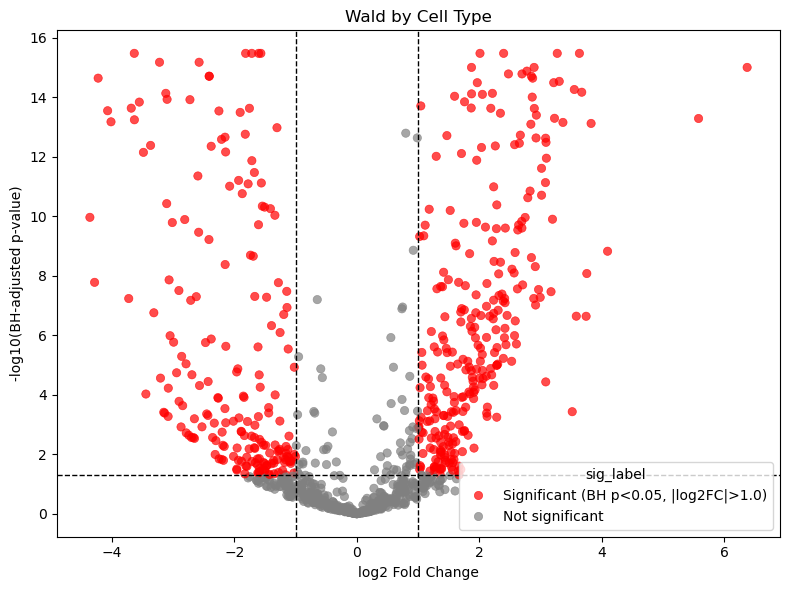

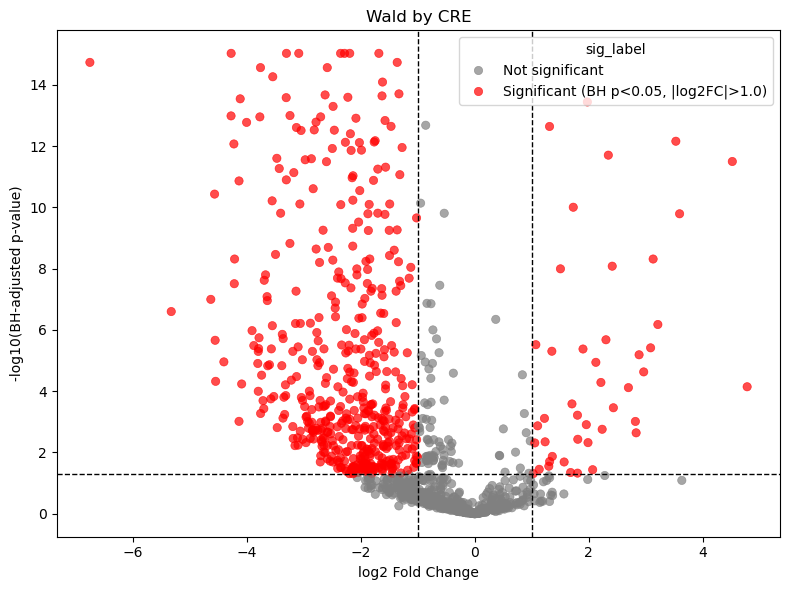

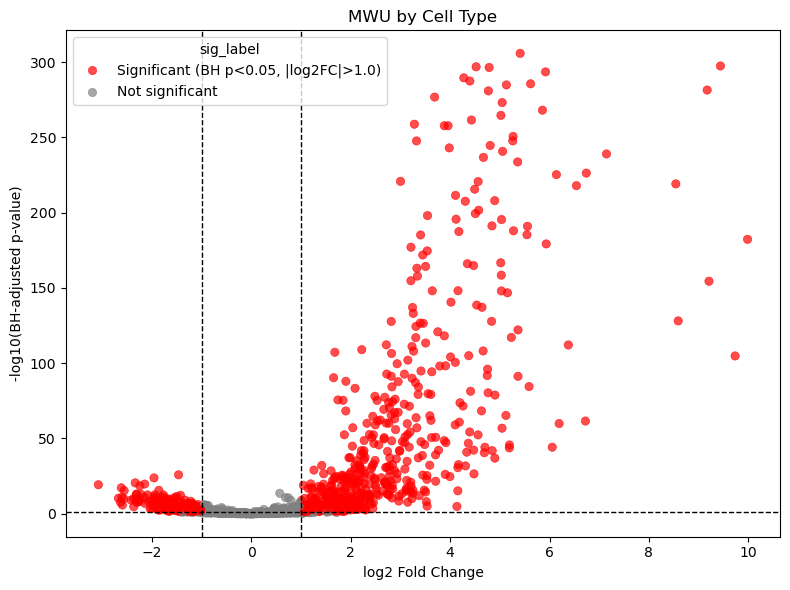

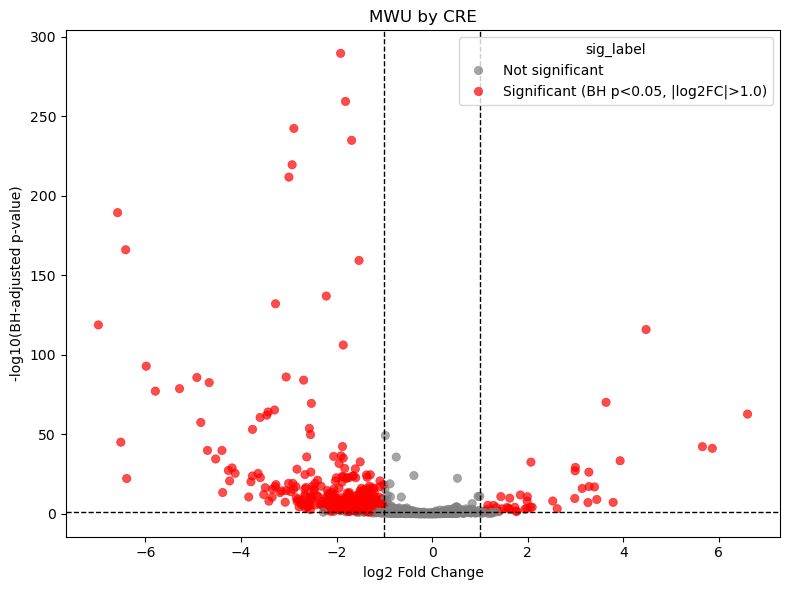

In [13]:
scm.volcano(wald_by_ct, title="Wald by Cell Type")
scm.volcano(wald_by_cre, title = 'Wald by CRE')
scm.volcano(mwu_res_ct, title = 'MWU by Cell Type')
scm.volcano(mwu_res_cre, title = 'MWU by CRE')

In [ ]:
mwu_res

canonicalize
bundle
map
client submit dispatch wald
stitch and out


comparison_CRE comparison_cell_type reference_CRE  \
0        Bend5_chr4_8175       Cardiomyocytes     reference   
1     Cdk5r1_chr11_12559       Cardiomyocytes     reference   
2     Col1a1_chr11_15322       Cardiomyocytes     reference   
3         Col1a2_chr6_77       Cardiomyocytes     reference   
4     Igfbp4_chr11_16711       Cardiomyocytes     reference   
...                  ...                  ...           ...   
1446   Txndc12_chr4_7973            reference     reference   
1447    Lama1_chr17_7787            reference     reference   
1448   Epas1_chr17_10064            reference     reference   
1449     Btg1_chr10_9578            reference     reference   
1450  Igfbp4_chr11_16694            reference     reference   

     reference_cell_type          meta  test_statistic       p_value  \
0         Cardiomyocytes  emvar_screen         25246.5  2.364681e-58   
1         Cardiomyocytes  emvar_screen         53572.0  2.047382e-16   
2         Cardiomyocytes  emvar_screen         14121.0  3.956297e-04   
3         Cardiomyocytes  emvar_screen         25934.5  5.874620e-02   
4         Cardiomyocytes  emvar_screen         15121.0  8.211205e-03   
...                  ...           ...             ...           ...   
1446           reference  emvar_screen       3878405.0  0.000000e+00   
1447           reference  emvar_screen        902038.5  1.062349e-04   
1448           reference  emvar_screen       1047294.5  3.689841e-03   
1449           reference  emvar_screen       1835252.0  0.000000e+00   
1450           reference  emvar_screen        773906.0  8.161109e-01   

      fold_change  flattened  ref_mean  comp_mean test_type          bh_p  
0       33.003656       True  0.024053   1.113858       mwu  1.531764e-57  
1        6.230655       True  0.024053   0.202169       mwu  7.483002e-16  
2        3.430988       True  0.024053   0.106834       mwu  8.073963e-04  
3        1.580133       True  0.024053   0.043807       mwu  8.706920e-02  
4        2.435112       True  0.024053   0.072922       mwu  1.437208e-02  
...           ...        ...       ...        ...       ...           ...  
1446    14.526987       True  0.107775   1.700917       mwu  0.000000e+00  
1447     0.277101       True  0.107775   0.022636       mwu  2.293853e-04  
1448     0.494174       True  0.107775   0.048201       mwu  6.751526e-03  
1449    36.953790       True  0.107775   4.342235       mwu  0.000000e+00  
1450     0.760821       True  0.107775   0.079606       mwu  8.458407e-01  

[1451 rows x 13 columns]

# setup bootstrap for simulations

In [ ]:

#create dask cluster
from dask.distributed import Client, LocalCluster
cluster=LocalCluster(n_workers=10)
client = Client(cluster)

path="/gpfs/gibbs/pi/reilly/tabula_data/simulated/simple_de_novo"
name="ortho_primordial"
precomp_name = 'ortho_primordial_wald_precomp'

import os
if os.path.isdir(path+"/"+precomp_name):
    print("[+]PreComp Model found. Loading...")
    primordial=scm.ortho.load(client,path,precomp_name)
    shendure=primordial.training_data
elif os.path.isdir(path+"/"+name):
    print("[+] Model found. Loading...")
    primordial=scm.ortho.load(client,path,name)
    shendure=primordial.training_data
    primordial.precompute_wald(client)
    primordial.save(path, precomp_name) 